Hola &#x1F600;

Soy **Hesus Garcia**  como "Jesús" pero con H. Sé que puede ser confuso al principio, pero una vez que lo recuerdes, ¡nunca lo olvidarás! &#x1F31D;	. Como revisor de código de Triple-Ten, estoy emocionado de examinar tus proyectos y ayudarte a mejorar tus habilidades en programación. si has cometido algún error, no te preocupes, pues ¡estoy aquí para ayudarte a corregirlo y hacer que tu código brille! &#x1F31F;. Si encuentro algún detalle en tu código, te lo señalaré para que lo corrijas, ya que mi objetivo es ayudarte a prepararte para un ambiente de trabajo real, donde el líder de tu equipo actuaría de la misma manera. Si no puedes solucionar el problema, te proporcionaré más información en la próxima oportunidad. Cuando encuentres un comentario,  **por favor, no los muevas, no los modifiques ni los borres**.

Revisaré cuidadosamente todas las implementaciones que has realizado para cumplir con los requisitos y te proporcionaré mis comentarios de la siguiente manera:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

</br>

**¡Empecemos!**  &#x1F680;



# Tienda ICE venta de Videojuegos 

# Objetivo
Verificar las tendencias de los videojuegos, para tener un mejor panorama para el futuro 2017 en adelante, al ver cual genero es el de mayor ventas y que consola es la que les agrada mas a los videojugadores.

In [1]:
#Se cargan todas las librerias para comenzar con el analisis
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt

In [2]:
#Se leera el archivo de Ice Venta de Videojuegos

dfvideojuegos=pd.read_csv('/datasets/games.csv')

dfvideojuegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
La carga de librerías necesarias y la lectura del archivo CSV fueron correctamente implementadas. El uso de `pd.read_csv` y la revisión inicial de los datos con `dfvideojuegos.info()` es un paso importante para entender la estructura del dataset antes de trabajar con él.
</div>


In [3]:
#Se cambiaron los nombres de las columnas a minusculas creando un diccionario y asignando las columnas a las nuevas columnas.

new_columns={'Name':'name',
            'Platform':'platform',
           'Year_of_Release':'year_of_release',
           'Genre':'genre',
           'NA_sales':'na_sales',
           'EU_sales':'eu_sales',
           'JP_sales':'jp_sales',
           'Other_sales':'other_sales',
           'Critic_Score':'critic_score',
           'User_Score':'user_score',
           'Rating':'rating'}

dfvideojuegos.rename(columns=new_columns,inplace=True)
dfvideojuegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
#Se llenaran los valores ausentes de name a unknown

dfvideojuegos[dfvideojuegos['name'].isna()]
dfvideojuegos['name'].fillna('unknown',inplace=True)

In [5]:
#Se valido que no hubiera valores duplicados antes de cambiar los valores ausentes
dfvideojuegos[dfvideojuegos.duplicated()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [6]:
dfvideojuegos[~dfvideojuegos['year_of_release'].isna()].mean()

year_of_release    2006.484616
na_sales              0.264089
eu_sales              0.145945
jp_sales              0.078479
other_sales           0.047593
critic_score         68.994363
dtype: float64

In [7]:
dfvideojuegos[~dfvideojuegos['year_of_release'].isna()].median()

year_of_release    2007.00
na_sales              0.08
eu_sales              0.02
jp_sales              0.00
other_sales           0.01
critic_score         71.00
dtype: float64

In [8]:
#Se llenaran los valores nulos o austentes de la columna year of release con la mediana, ya qe no hay mucha variacion con respecto a la media
#Se cambiara el tipo de columna de year of release a tipo int ya que no hay necesidad de que sea float
dfvideojuegos['year_of_release'].fillna(dfvideojuegos['year_of_release'].median(),inplace=True)
dfvideojuegos['year_of_release'].unique()
dfvideojuegos['year_of_release']=dfvideojuegos['year_of_release'].astype(int)

In [9]:
#Se llenara el valor nulo de genre con la palabra 'unknown'
dfvideojuegos[dfvideojuegos['genre'].isna()]
dfvideojuegos['genre'].unique()
dfvideojuegos['genre'].fillna('unknown',inplace=True)
dfvideojuegos['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', 'unknown'], dtype=object)

In [10]:
#Las columnas de na_sales, eu_sales, jp_sales al igual que other_sales se mantienen en el mismo tipo de dato float64
#La columna critic score se cambio a tipo int y se llenaron los valores ausentes por la mediana ya que hay valores atipicos.
#La columna user score se dejara en float pero se cambiaran los valores ausentes por la media o mediana

dfvideojuegos['critic_score'].fillna(dfvideojuegos['critic_score'].median(),inplace=True)
dfvideojuegos['critic_score']=dfvideojuegos['critic_score'].astype(int)

dfvideojuegos['user_score'].fillna(100,inplace=True)
dfvideojuegos['user_score'].replace("tbd",100,inplace=True)
dfvideojuegos['user_score']=dfvideojuegos['user_score'].astype(float)

dfvideojuegos[dfvideojuegos['user_score']!=100].median()

dfvideojuegos['user_score'].replace(100,7.50,inplace=True)

In [11]:
#Se coloco la palabra unknown en lo que son los valores ausentes de los ratings de los videojuegos ya que no se tiene un rating
dfvideojuegos['rating'].fillna('unknown',inplace=True)

In [12]:
dfvideojuegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [13]:
dfvideojuegos['ventas_totales']=dfvideojuegos['na_sales']+dfvideojuegos['eu_sales']+dfvideojuegos['jp_sales']+dfvideojuegos['other_sales']

In [14]:
dfvideojuegos.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,71,7.5,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,71,7.5,unknown,31.38


# Conclusion limpieza de datos

Se hicieron los siguientes cambios

-Las columnas se cambiaon de mayusculas a minusculas primeramente.

-La columna de year of release se cambio de tipo float a tipo int ya que no hay years en decimal, y se llenaron los valores ausentes con la mediana ya que se vieron valores atipicos.

-La columna de critic score tambien se cambio de tipo float a tipo int ya que no se contenian valores decimales que podrian hacer que esta columna estuviera en este tipo de dato, al igual que los valores ausentes se cambiaron por la mediana.

-La columna user score se cambio de un tipo de dato string a tipo float ya que se contenian calificaciones de los usuarios en valores decimales, al igual que los valores ausentes como tbd y nan se llenaron con la mediana.

-Valores tbd en la columna user score se pueden deber a que la persona que llena los datos no tenia alguna idea de la calificacion de los usuarios o no se contenia en este momento que se hizo el estudio, es por esto que se le colo tbd que significa to be determine (se colocara posteriormente).

-Los valores ausentes de rating se colocaron con unknown ya que no se tiene el rating de cada uno de los juegos y ya que son letras como valores string no se pueden llenar tal cual ya que existen muchos ratings dependiendo de la audiencia de los jugadores, es por esto que se dejo como unknown.

Estas fueron las consideraciones que se hicieron en este proyecto para poder tener la informacion mas completa y no tenerla sesgada.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El proceso de limpieza de datos fue bien estructurado y coherente. La decisión de cambiar las columnas a minúsculas mejora la legibilidad y consistencia del código. Además, la imputación de valores nulos utilizando la mediana en `year_of_release` y `critic_score` es una elección lógica para mitigar el impacto de los valores atípicos. También se manejaron adecuadamente los valores de `user_score` y `rating`, utilizando una imputación razonable para datos faltantes y valores como 'tbd'.
</div>



<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Para mejorar aún más, podrías añadir gráficos que muestren la distribución de las calificaciones (`user_score` y `critic_score`) antes y después de la imputación, para visualizar cómo el proceso de limpieza afectó la estructura de los datos.
</div>


# Analisis de datos

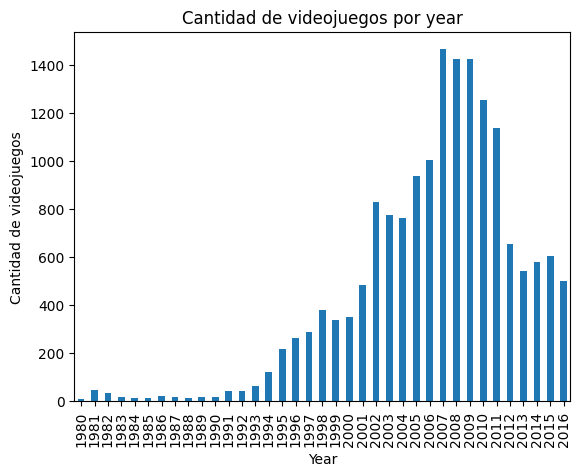

In [15]:
#Se analizaran los juegos que salieron por year.

years=dfvideojuegos.groupby('year_of_release')['platform'].count()

years.plot(kind='bar',
           ylabel = 'Cantidad de videojuegos',
           xlabel = 'Year',
           title='Cantidad de videojuegos por year')

plt.show()

#Se pueden observar que los years en los que se encuentran mayores juegos o salieron mas juegos son del 2006 al 2011
#Los valores no son significativos simplemente se ve una tendencia a la alta en ese periodo de tiempo, pueden ser varios factores como consolas que salieron
#o simplemente que las personas tenian mas interes en la compra de videojuegos o salio un videojuego que rompio el mercado.

In [16]:
print(dfvideojuegos.groupby('platform')['ventas_totales'].sum().sort_values(ascending=False))

ventasps2=dfvideojuegos['platform']=="PS2"
ventasx360=dfvideojuegos['platform']=='X360'
ventasps3=dfvideojuegos['platform']=='PS3'

totalventasps2=dfvideojuegos[ventasps2]['year_of_release'].value_counts()
totalventasx360=dfvideojuegos[ventasx360]['year_of_release'].value_counts()
totalventasps3=dfvideojuegos[ventasps3]['year_of_release'].value_counts()

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: ventas_totales, dtype: float64


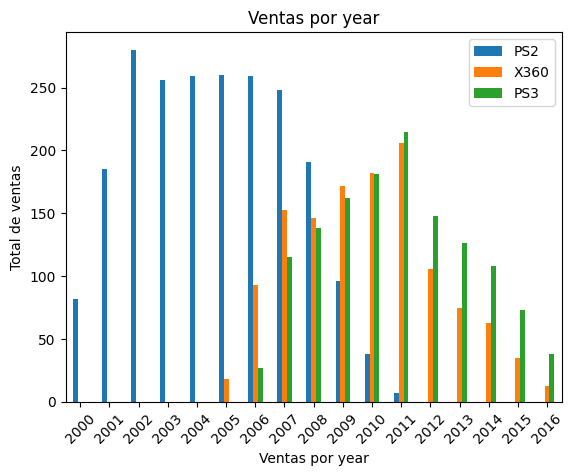

In [17]:
totalventastop3=pd.concat([totalventasps2,totalventasx360,totalventasps3],axis=1)

totalventastop3.columns=['PS2','X360','PS3']

totalventastop3.plot(kind='bar',
                     title='Ventas por year',
                     xlabel='Ventas por year', 
                     ylabel='Total de ventas',
                     rot=45)
plt.show()

#Se puede observar que al 2007 PS2 va a la baja y PS3 va a la alza, esto significa que despues de 3 años de salir la nueva consola la vieja va a la baja PS2

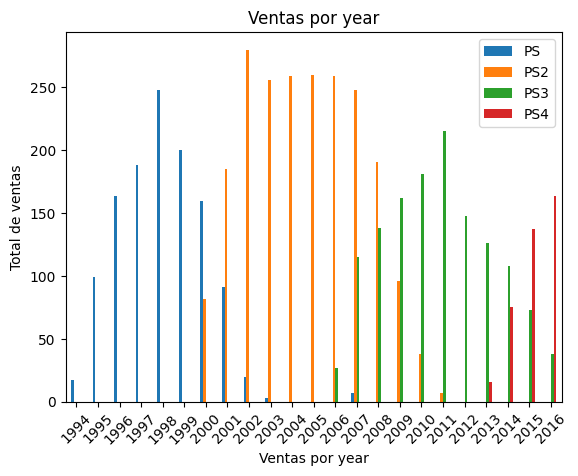

In [18]:
#Se analizaran los cambios de consolas como PS, PS2, PS3 y PS4 lo cual nos puede dar un panorama de que pasa con las consolas viejas.
ventasps=dfvideojuegos['platform']=="PS"
ventasps2=dfvideojuegos['platform']=="PS2"
ventasps3=dfvideojuegos['platform']=='PS3'
ventasps4=dfvideojuegos['platform']=='PS4'

totalventasps=dfvideojuegos[ventasps]['year_of_release'].value_counts()
totalventasps2=dfvideojuegos[ventasps2]['year_of_release'].value_counts()
totalventasps3=dfvideojuegos[ventasps3]['year_of_release'].value_counts()
totalventasps4=dfvideojuegos[ventasps4]['year_of_release'].value_counts()

totalventasps=pd.concat([totalventasps,totalventasps2,totalventasps3,totalventasps4],axis=1)

totalventasps.columns=['PS','PS2','PS3','PS4']

totalventasps.plot(kind='bar',
                     title='Ventas por year',
                     xlabel='Ventas por year', 
                     ylabel='Total de ventas',
                     rot=45)
plt.show()

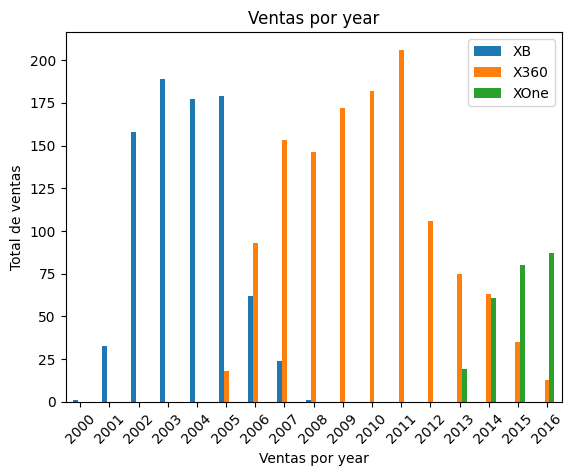

In [19]:
#Se analizaran los cambios de consolas como xbox,xbox360 y xboxone lo cual nos puede dar un panorama de que pasa con las consolas viejas.
ventasxb=dfvideojuegos['platform']=="XB"
ventasx360=dfvideojuegos['platform']=="X360"
ventasxone=dfvideojuegos['platform']=='XOne'

totalventasxb=dfvideojuegos[ventasxb]['year_of_release'].value_counts()
totalventasx360=dfvideojuegos[ventasx360]['year_of_release'].value_counts()
totalventasxone=dfvideojuegos[ventasxone]['year_of_release'].value_counts()

totalventasxb=pd.concat([totalventasxb,totalventasx360,totalventasxone],axis=1)

totalventasxb.columns=['XB','X360','XOne']

totalventasxb.plot(kind='bar',
                     title='Ventas por year',
                     xlabel='Ventas por year', 
                     ylabel='Total de ventas',
                     rot=45)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El análisis de las tendencias de videojuegos por año está bien planteado y el uso de gráficos de barras permite visualizar claramente los patrones de lanzamientos. Identificar los picos entre 2006 y 2011 es un hallazgo importante, ya que ayuda a entender la dinámica del mercado de videojuegos durante ese periodo. Además, la comparación de ventas entre consolas de diferentes generaciones (PS2, PS3, PS4, XB, X360, XOne) está bien lograda y permite observar el comportamiento decreciente de las consolas antiguas en favor de las nuevas.
</div>



<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El análisis de las consolas PS y Xbox está bien desarrollado, pero podrías expandir el análisis para incluir otras plataformas populares de la época, como Nintendo. Esto proporcionaría una perspectiva más amplia de las preferencias de los jugadores durante estos años.
</div>


# Conclusiones analisis ventas

-Como se pueden observar en dos consolas tanto Playstation como Xbox, al tercer año de salir la nueva consola, la vieja se elimina y se ve afectada por las ventas de esta nueva.

-Se tomaran en cuenta los datos desde el 2013 ya que es donde se encuentran las nuevas consolas para poder hacer un analisis para el 2017.

In [20]:
años={2013,2014,2015,2016}

filtroanalisis=dfvideojuegos[dfvideojuegos['year_of_release'].isin(años)]

filtroanalisis.groupby(['year_of_release','platform'])['ventas_totales'].sum().sort_values

#Los lideres de ventas de plataformas para lo que es 2013 es PS3, para 2014, 2015 y 2016 es PS4, consola de nueva generacion.
#Las plataformas que se reducen son PS3 ya que salio la PS4 nueva,PC tambien es una que baja sus ventas, al igual que 3DS, por mencionar a algunas.

<bound method Series.sort_values of year_of_release  platform
2013             3DS          56.57
                 DS            1.54
                 PC           12.38
                 PS3         113.25
                 PS4          25.99
                 PSP           3.14
                 PSV          10.59
                 Wii           8.59
                 WiiU         21.65
                 X360         88.58
                 XOne         18.96
2014             3DS          43.76
                 PC           13.28
                 PS3          47.76
                 PS4         100.00
                 PSP           0.24
                 PSV          11.90
                 Wii           3.75
                 WiiU         22.03
                 X360         34.74
                 XOne         54.07
2015             3DS          27.78
                 PC            8.52
                 PS3          16.82
                 PS4         118.90
                 PSP           0.12
  

Grafica de Caja de PS4


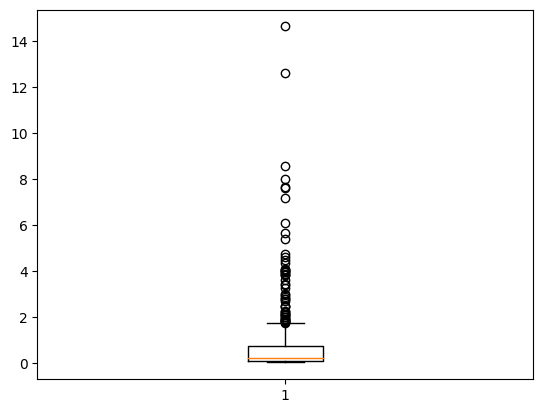


Grafica de Caja Xone


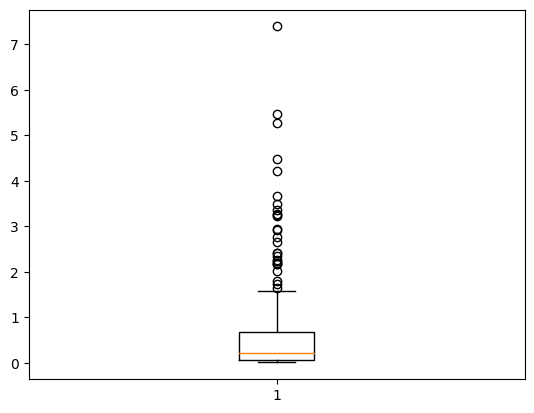


Grafica de Caja 3DS


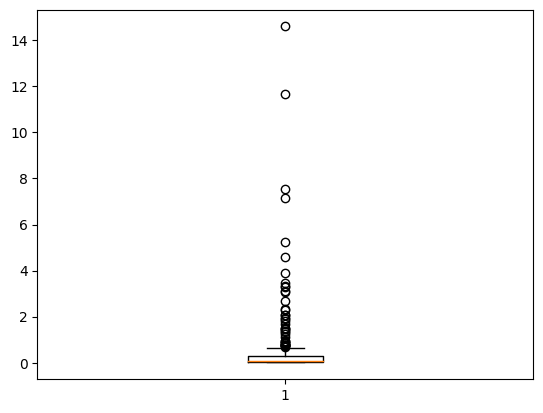

In [21]:
print('Grafica de Caja de PS4')
plt.boxplot(filtroanalisis.query('platform =="PS4"')['ventas_totales'])
plt.show()

print('')

print('Grafica de Caja Xone')

plt.boxplot(filtroanalisis.query('platform =="XOne"')['ventas_totales'])
plt.show()

print('')

print('Grafica de Caja 3DS')

plt.boxplot(filtroanalisis.query('platform =="3DS"')['ventas_totales'])
plt.show()

print('')

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Has hecho un excelente trabajo al identificar las tendencias en las ventas de consolas y cómo las nuevas generaciones afectan las anteriores. El análisis por años es claro y bien estructurado, y las gráficas de caja utilizadas para comparar la dispersión de ventas entre las consolas (PS4, XOne, 3DS) son una excelente elección visual. Esto permite observar las diferencias en las ventas de manera efectiva y resalta los patrones de mercado.
</div>


# Conclusion graficas de Caja


En el filtrado de datos de 2013, se puede observar que las medias de las diferentes consolas como PS4, Xone y 3DS se encuentran muy similares por debajo de 1 e incluso por debajo de 0.5 en el global de ventas totales de todos los videojuegos, esto nos da una idea de que todos se encuentran en los mismos rangos ya que comparamos 3 consolas y nos arrojaron los datos muy parecidos.

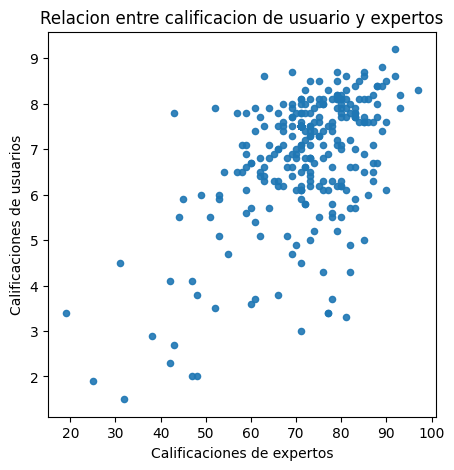

In [22]:
#Se filtran los datos para sacar los de una consola en especifico como lo es el PS4 y se pasa a realizar un diagrama de dispersion entre las dos calificaciones.

filtrops4=filtroanalisis[filtroanalisis['platform']=='PS4']

filtrops4.plot(y='user_score',
               x='critic_score',
               title='Relacion entre calificacion de usuario y expertos',
               xlabel='Calificaciones de expertos',
               ylabel='Calificaciones de usuarios',
               figsize=[5,5],
               alpha=0.9,
               kind='scatter')

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Has realizado un excelente trabajo al identificar que las ventas totales de las consolas PS4, XOne y 3DS presentan rangos muy similares en las gráficas de caja, lo cual permite observar patrones de ventas en el mercado de videojuegos. Además, la transición a la visualización de la relación entre las calificaciones de usuarios y críticos mediante un gráfico de dispersión es una decisión acertada para comparar dos métricas importantes y descubrir correlaciones entre ellas. Es una buena forma de profundizar en el análisis.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Se encuentra un detalle en la manera en que estás configurando el gráfico de dispersión. El argumento `x` y `y` en el gráfico de dispersión parecen estar mal colocados. El eje X debería representar la variable `critic_score`, mientras que el eje Y debe mostrar `user_score`, pero actualmente el orden de los parámetros está invertido. Esto puede llevar a una visualización incorrecta de la relación entre ambas variables.

**Cómo corregirlo paso a paso**:
1. Verifica el orden en que pasas las columnas para los ejes del gráfico. Recuerda que `x` debe representar las calificaciones de los expertos (`critic_score`) y `y` debe mostrar las calificaciones de los usuarios (`user_score`).
2. Asegúrate de que el gráfico refleje correctamente la relación que estás intentando analizar: cómo las calificaciones de los expertos afectan o están correlacionadas con las de los usuarios.
3. Ejecuta el código nuevamente después de corregir el orden de los parámetros para confirmar que la visualización se ajusta a la interpretación deseada.

Ajustando estos detalles, el gráfico de dispersión mostrará la relación de forma más precisa.
</div>


# Conclusiones Diagramas de Dispersion

Se puede observar que a mayor calificaciones de los expertos existe una relacion igual con los usuarios en la que los usuarios tambien evaluan de buena forma al videojuego, es decir, ambos consideran una joya a un juego en especifico.

In [23]:
filtroanalisis[filtroanalisis['name']=="Grand Theft Auto V"]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97,8.1,M,16.27
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97,8.3,M,12.62
165,Grand Theft Auto V,XOne,2014,Action,2.81,2.19,0.00,0.47,97,7.9,M,5.47
1730,Grand Theft Auto V,PC,2015,Action,0.39,0.69,0.00,0.09,96,7.9,M,1.17


In [24]:
filtroanalisis[filtroanalisis['name']=="Call of Duty: Ghosts"]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73,2.6,M,10.24
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71,2.6,M,9.36
323,Call of Duty: Ghosts,PS4,2013,Shooter,1.78,1.43,0.05,0.57,78,3.7,M,3.83
493,Call of Duty: Ghosts,XOne,2013,Shooter,1.88,0.77,0.00,0.27,78,4.3,M,2.92
2916,Call of Duty: Ghosts,PC,2013,Shooter,0.23,0.41,0.00,0.05,71,7.5,unknown,0.69
5348,Call of Duty: Ghosts,WiiU,2013,Shooter,0.22,0.09,0.01,0.03,69,3.4,M,0.35


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El análisis de la relación entre las calificaciones de usuarios y críticos está bien planteado. Has identificado correctamente que, en general, existe una correlación positiva: cuando los críticos consideran un videojuego excelente, los usuarios tienden a estar de acuerdo. Esta conclusión refleja una buena interpretación de los datos y muestra cómo las calificaciones de ambas partes coinciden, lo que es valioso para los desarrolladores y analistas del mercado.
</div>




# Conclusion mismo juego diferente consola

Se puede observar que un ejemplo de juego en el que se comparte con las diferentes plataformas como lo es el Grand Theft Auto V, las ventas de las primeras consolas fueron mayores a las que posteriormente salieron, como se puede observar en el PS3 y X360 en las cuales tuvieron mayores ventas.

En lo que se refiere a las calificaciones de las criticas y las calificaciones de los usuarios no hay mucha diferencia significativa solo son 0.4 puntos de diferencia en la calificacion de los usuarios y de los expertos es de 1.

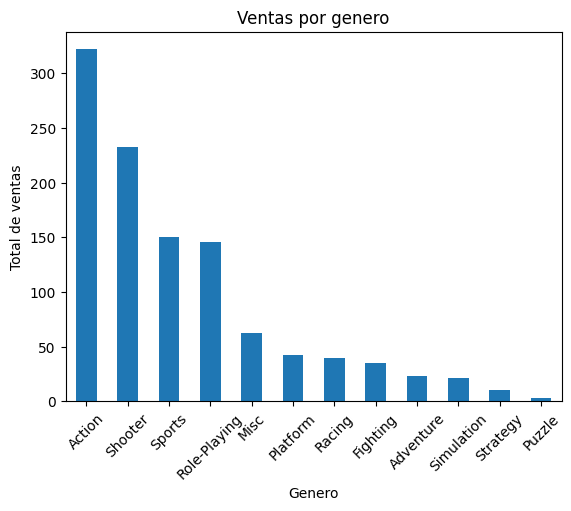

In [25]:
generos=filtroanalisis.groupby('genre')['ventas_totales'].sum().sort_values(ascending=False)

generos.plot(kind='bar',
             title='Ventas por genero',
             xlabel='Genero', 
             ylabel='Total de ventas',
             rot=45)
plt.show()

#Se puede observar que los juegos de accion son los que mas se venden a lo largo de todo el mundo.

# Conclusiones grafica por genero

Se puede observar que la mayor cantidad de ventas se encuentran en los generos de accion y shooters, lo cual es un genero que le gusta a la mayor cantidad de jugadores a lo largo de todo el mundo, caso contrario los que menos se venden son los de simulacion, estrategia y de rompecabezas que son los que no les gustan a las personas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El análisis de las ventas de videojuegos en diferentes consolas está bien planteado, especialmente al señalar que los juegos como *Grand Theft Auto V* tuvieron mayores ventas en consolas más antiguas como PS3 y X360. Esto demuestra que los usuarios no necesariamente migran inmediatamente a las nuevas consolas, lo cual es una observación importante para la industria. Además, has notado correctamente que las diferencias en las calificaciones entre críticos y usuarios son mínimas, lo que refuerza la idea de una fuerte coincidencia en la percepción de la calidad del juego.
</div>




# Conclusiones generales analisis de datos

1) Se puede observar que las consolas nuevas vienen a la baja 3 años despues de que la consola nueva esta en el mercado eso lo podemos ver con las consolas de PS3 y PS4, X360 y XOne como ejemplos en los que la consola nueva ya empieza a tener mayor cantidad de ventas que las antecesora.

2) Para tener un modelo mejor para lo que es el 2017 se tomaron los datos de 2013 para adelante ya que es el periodo de tiempo en el que se encuentran las ultimas consolas, sus inicios.

3) Las ventas promedio de estos años han estado muy similares en las diferentes plataformas como lo son PS4, XOne y 3Ds como lo podemos observar en las graficas de caja que tenemos en la parte posterior.

4) Las ventas totales tambien se pueden dividir por genero, en el cual la mayor cantidad de ventas se encuentran en los generos de accion y shooters, siendo los mas bajos los de rompecabezas y de estrategia.

5) Tambien se observaron que hay juegos en los que salieron para varias plataformas, lo cual se vieron que las ventas mayores se encuentran en lo que son las primeras consolas como lo es el Grand Thef Auto V y las calificaciones tanto de los expertos como de los usuarios no cambian mucho.

In [26]:
filtrona=filtroanalisis.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
filtrona

platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
WiiU     29.21
PC       11.11
Wii       6.56
PSV       5.04
DS        0.57
PSP       0.00
Name: na_sales, dtype: float64

In [27]:
filtroeu=filtroanalisis.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
filtroeu

platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
PC       25.36
WiiU     19.85
PSV       6.10
Wii       5.93
DS        0.85
PSP       0.17
Name: eu_sales, dtype: float64

In [28]:
filtrojp=filtroanalisis.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
filtrojp

platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
PSP      3.29
X360     0.51
XOne     0.34
Wii      0.05
DS       0.00
PC       0.00
Name: jp_sales, dtype: float64

In [29]:
filtrona=pd.concat([filtrona,filtroeu,filtrojp],axis=1)

filtrona.columns=['na_sales','eu_sales','jp_sales']

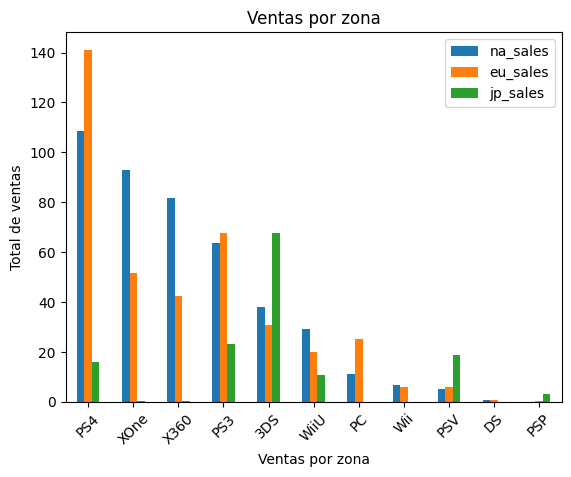

In [30]:
filtrona.plot(kind='bar',
              title='Ventas por zona',
              xlabel='Ventas por zona', 
              ylabel='Total de ventas',
              rot=45)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Excelente trabajo en las conclusiones! Has identificado de manera precisa el patrón en el que las ventas de consolas antiguas comienzan a decaer aproximadamente tres años después del lanzamiento de una nueva consola. Este es un hallazgo relevante y bien fundamentado.  También destacaste correctamente cómo los géneros más populares son acción y shooters, lo cual es un insight importante para entender las preferencias del mercado.
Tus gráficos están bien estructurados y claros, lo que facilita la interpretación de los resultados. Estás en el camino correcto, ¡continúa explorando más formas de visualizar los datos y profundiza en las razones detrás de estas tendencias!
</div>


# Conclusion grafica por zonas

Se puede observar que las ventas de PS4 tanto en NA y en EU es la mayor con respecto a las otras.

Pero en lo que respecta a las ventas de JP las ventas son mas de la consola 3DS que es marca de nintendo que es japoneas originalmente la consola.

In [31]:
filtrogenerona=filtroanalisis.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
filtrogenerona

genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Platform         18.14
Fighting         15.55
Racing           12.96
Adventure         7.14
Simulation        4.86
Strategy          3.28
Puzzle            0.83
Name: na_sales, dtype: float64

In [32]:
filtrogeneroeu=filtroanalisis.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
filtrogeneroeu

genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Misc             20.04
Platform         15.58
Simulation       10.92
Fighting          8.55
Adventure         8.25
Strategy          4.22
Puzzle            1.00
Name: eu_sales, dtype: float64

In [33]:
filtrogenerojp=filtroanalisis.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
filtrogenerojp

genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Adventure        5.82
Sports           5.41
Platform         4.79
Simulation       4.52
Racing           2.30
Strategy         1.77
Puzzle           1.18
Name: jp_sales, dtype: float64

In [34]:
filtrogenerona=pd.concat([filtrogenerona,filtrogeneroeu,filtrogenerojp],axis=1)

filtrogenerona.columns=['na_sales','eu_sales','jp_sales']

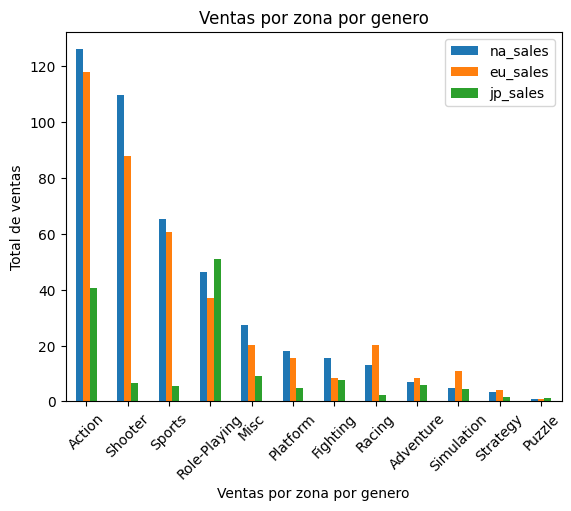

In [35]:
filtrogenerona.plot(kind='bar',
                    title='Ventas por zona por genero',
                    xlabel='Ventas por zona por genero', 
                    ylabel='Total de ventas',
                    rot=45)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El análisis de ventas por zona geográfica esta bien. Destacas de manera clara que las ventas de la PS4 son dominantes en Norteamérica y Europa, mientras que en Japón la 3DS de Nintendo tiene mayor relevancia, es un insight importante sobre las preferencias regionales. 
Tus gráficos están bien estructurados y fáciles de interpretar, lo que refuerza la narrativa de tu análisis. ¡Excelente trabajo mostrando las diferencias regionales de manera visual.
</div>


# Conclusiones por genero

Se pueden observar que al igual que en las plataformas hay una consistencia en cuestion de los generos, ya que los generos que continen mayores ventas son de accion y shooter en lo que son NA y EU, por lo tanto en JP los que tienen mayor cantidad de ventas son los juegos de role playing que son los llamados RPG que son originarios en su mayoria en japon, de ahi que son los que tienen la mayor cantidad de ventas.

Si existe una diferencia significativa en cuanto a los generos por zona.

In [36]:
filtroratingna=filtroanalisis.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
filtroratingna

rating
M          165.21
unknown     89.42
E           79.05
E10+        54.24
T           49.79
Name: na_sales, dtype: float64

In [37]:
filtroratingeu=filtroanalisis.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
filtroratingeu

rating
M          145.32
E           83.36
unknown     78.91
E10+        42.69
T           41.95
Name: eu_sales, dtype: float64

In [38]:
filtroratingjp=filtroanalisis.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
filtroratingjp

rating
unknown    85.05
T          20.59
E          15.14
M          14.11
E10+        5.89
Name: jp_sales, dtype: float64

In [39]:
filtroratingna=pd.concat([filtroratingna,filtroratingeu,filtroratingjp],axis=1)

filtroratingna.columns=['na_sales','eu_sales','jp_sales']

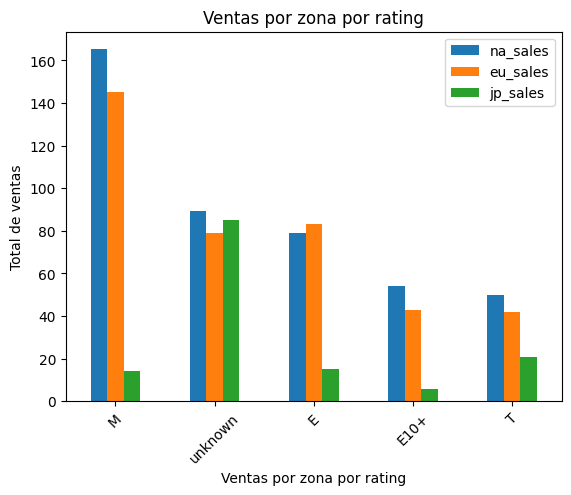

In [40]:
filtroratingna.plot(kind='bar',
                    title='Ventas por zona por rating',
                    xlabel='Ventas por zona por rating', 
                    ylabel='Total de ventas',
                    rot=45)
plt.show()

# Conclusiones por rating

Se puede observar que las mayores ventas tienen el rating de M que es mature o maduro para personas mayores de edad que tiene sentido por los juegos que se encuentran con mayores ventas como lo son los juegos de accion y de disparos o shooters, en segundo lugar se encuentran los desconocidos que no sabemos que clasificacion sean, y posteriormente los E de everyone o para todo el publico en general. Podriamos pensar que los unknown tienen relacion con los juegos role play de japon ya que son los que mayores ventas tienen pero tendriamos que revisar bien lo que son los juegos unknown para esta zona.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Muy bien hecho! Identificas  correctamente que los géneros de acción y shooters dominan las ventas en Norteamérica y Europa, mientras que en Japón los juegos de rol (RPG) son los más populares. Esto refleja una comprensión sólida de las diferencias culturales en las preferencias de videojuegos. Es un hallazgo importante y relevante para el análisis.

Tus gráficos de barras por género y por zona refuerzan claramente esta narrativa y proporcionan una visualización efectiva de las tendencias.
</div>


# Prueba de hipotesis

Se estara usando la prueba para comparar las dos medias muestrales de los diferentes juegos de Xbox One y PC con un alpha de 0.5%, seria la ttest independiente ya que son medias muestrales de dos muestras diferentes.

Hipotesis Nula: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Hipotesis Alternativa: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

In [88]:
filtroXone=filtroanalisis.query('platform=="XOne"')['user_score']
filtroPC=filtroanalisis.query('platform=="PC"')['user_score']
alpha=0.05

In [89]:
hipotesis=st.ttest_ind(filtroXone,filtroPC,equal_var=False)

print('Valor de p: ',hipotesis.pvalue)

if(hipotesis.pvalue>alpha):
  print("Rechazamos la hipotesis nula")
else:
  print('Aceptamos la hipotesis nula')

print('Por lo tanto las medias de las calificaciones de las consolas XOne y PC son iguales')

Valor de p:  0.04657158430650933
Aceptamos la hipotesis nula
Por lo tanto las medias de las calificaciones de las consolas XOne y PC son iguales


# Prueba de hipotesis 2


Hipotesis Nula: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Hipotesis Alternativa: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales

In [93]:
filtroaccion=filtroanalisis.query('genre=="Action"')['user_score']
filtrodeportes=filtroanalisis.query('genre=="Sports"')['user_score']
alpha2=0.05

In [94]:
hipotesis2=st.ttest_ind(filtroaccion,filtrodeportes,equal_var=False)

print('Valor de p: ',hipotesis2.pvalue)

if(hipotesis2.pvalue>alpha2):
  print("Rechazamos la hipotesis nula")
else:
  print('Aceptamos la hipotesis nula')

print('Por lo tanto las medias de las calificaciones de los generos de accion y deportes son diferentes')

Valor de p:  2.6150491502015005e-21
Aceptamos la hipotesis nula
Por lo tanto las medias de las calificaciones de los generos de accion y deportes son diferentes


# Conclusiones Generales

1) Inicialmente se reviso la informacion para verificar si habia duplicados los cuales no se encontraron.

2) Posteriormente se vieron las celdas que se tenian con valores nulos, los cuales eran en varias columnas tanto en las calificaciones de critica como en las calificaciones de usuarios mas que nada y se decidio rellenar esos espacios con la mediana ya que se tenian datos atipicos que podrian afectar el resultado.

3) Una vez llenado y limpiado los datos se procedio a realizar el analisis de los datos para saber la tendencia de las plataformas y ver como se veian decayendo en cuanto a ventas se refiera ya que se inicia el periodo de transicion con la consola mas nueva como ejemplo PS3 y PS4.

4) Tambien se observaron las tendencias por region siendo una de las mayores consolas en ventas el PS2 y los juegos de accion y shooters los que mas juegan los usuarios (ventas). 

5) Tambien se vio que los juegos en japon se ven mas inclinados a lo que son los juegos roleplay o RPG que son originarios en ese pais.

6) Por ultimo se hicieron varias pruebas de hipotesis para verificar si las medias de varias opciones como lo son de dos consolas como Xone y PC son las mismas lo cual resulto cierto y las medias de los juegos de accion y deportes lo cual resulto en que no son iguales.

7) Esto nos brinda un parametro de tendencia o al cual dirigirnos en los proximos años y la consola a la cual las personas estan comprando mas.

Fue un proyecto interesante y divertido.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Gran trabajo con la implementación de las pruebas de hipótesis! Has estructurado correctamente las hipótesis nulas y alternativas, y usaste el test t de manera adecuada para comparar las medias de las calificaciones de los usuarios entre diferentes plataformas y géneros. Es muy positivo que hayas elegido un enfoque basado en datos para verificar si las diferencias son estadísticamente significativas, lo que añade profundidad a tu análisis. También es importante destacar cómo manejaste la interpretación del valor p y el nivel de significancia (alpha), lo cual demuestra un buen entendimiento de la inferencia estadística.

¡Sigue así, estás manejando conceptos avanzados de forma clara y efectiva! 
</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Felicidades! Tu proyecto ha sido **aprobado**. Has demostrado un excelente manejo de los datos, implementando pruebas de hipótesis con claridad y un análisis riguroso de las plataformas y géneros de videojuegos. Los gráficos que incluiste enriquecen el análisis y proporcionan una visualización clara de los resultados. 

Te animo a seguir trabajando con la misma dedicación y entusiasmo. Sigue profundizando en estas técnicas y explora nuevas áreas, porque ya has demostrado una gran habilidad en la ciencia de datos. 
</div>
